# ================================================
# Défi Quotidien : Régression Logistique - Admission Université
# ================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns


Premières lignes du dataset :
       Exam1      Exam2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1

Informations :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam1     100 non-null    float64
 1   Exam2     100 non-null    float64
 2   Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None

Statistiques :
            Exam1       Exam2    Admitted
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000


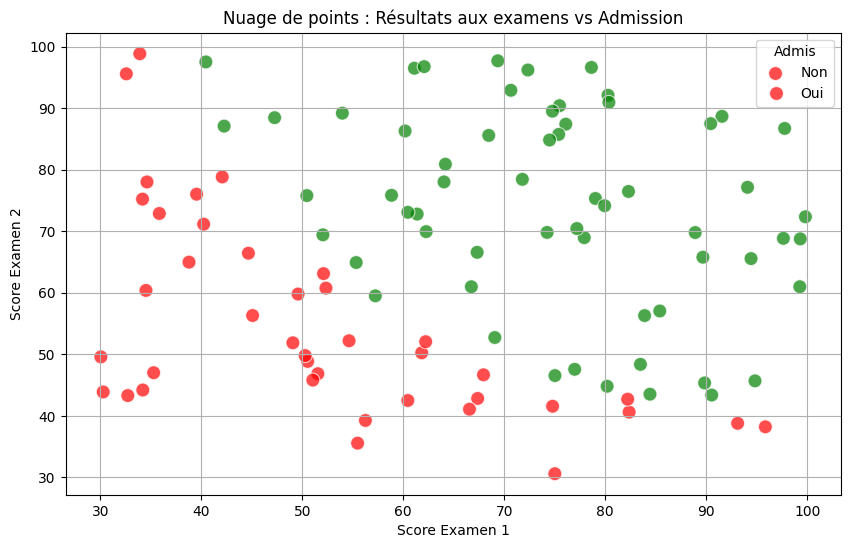

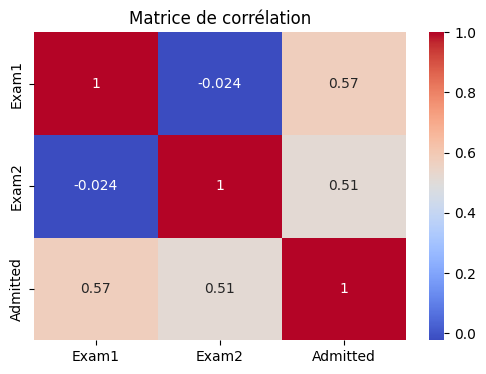


Modèle entraîné avec succès !

Précision du modèle : 80.00%

Rapport de classification :
              precision    recall  f1-score   support

   Non admis       0.70      0.88      0.78         8
       Admis       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20



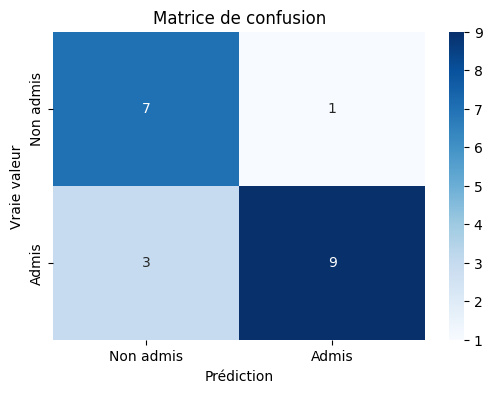


=== Interprétation ===
• Le modèle utilise une fonction sigmoïde pour prédire la probabilité d'admission.
• Précision globale : 80.00%
• Coefficients du modèle :
  Feature  Coefficient
0   Exam1     0.259702
1   Exam2     0.224810

Exemple : Un étudiant avec Exam1=80 et Exam2=90 a environ 100.0% de chances d'être admis.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [2]:

# ====================== 1. Chargement des données ======================
# Dataset classique (ex2data1) : Exam1, Exam2, Admis (0/1)
# Si tu as un lien direct CSV, remplace l'URL ci-dessous

url = "https://raw.githubusercontent.com/nedimm/Logistic-Regression/master/ex2data1.txt"  # ou ton lien
# Alternative locale si tu uploades le fichier :
# from google.colab import files
# uploaded = files.upload()
# data = pd.read_csv('ex2data1.txt', header=None, names=['Exam1', 'Exam2', 'Admitted'])

data = pd.read_csv(url, header=None, names=['Exam1', 'Exam2', 'Admitted'])
print("Premières lignes du dataset :")
print(data.head())
print("\nInformations :")
print(data.info())
print("\nStatistiques :")
print(data.describe())

# ====================== 2. Exploration & Visualisation ======================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Exam1', y='Exam2', hue='Admitted', palette={0: 'red', 1: 'green'}, s=100, alpha=0.7)
plt.title("Nuage de points : Résultats aux examens vs Admission")
plt.xlabel("Score Examen 1")
plt.ylabel("Score Examen 2")
plt.legend(title="Admis", labels=['Non', 'Oui'])
plt.grid(True)
plt.show()

# Matrice de corrélation
plt.figure(figsize=(6, 4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

# ====================== 3. Préparation des données ======================
X = data[['Exam1', 'Exam2']]
y = data['Admitted']

# Séparation train/test (optionnel mais bonne pratique)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ====================== 4. Modèle de Régression Logistique ======================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("\nModèle entraîné avec succès !")

# ====================== 5. Prédictions & Évaluation ======================
y_pred = model.predict(X_test)

# Précision
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrécision du modèle : {accuracy:.2%}")

# Rapport détaillé
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Non admis', 'Admis']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non admis', 'Admis'],
            yticklabels=['Non admis', 'Admis'])
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Vraie valeur")
plt.show()

# ====================== 6. Interprétation ======================
print("\n=== Interprétation ===")
print("• Le modèle utilise une fonction sigmoïde pour prédire la probabilité d'admission.")
print(f"• Précision globale : {accuracy:.2%}")
print("• Coefficients du modèle :")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coef_df)

# Prédiction exemple
exemple = np.array([[80, 90]])  # Exemple : scores aux deux examens
proba = model.predict_proba(exemple)[0][1]
print(f"\nExemple : Un étudiant avec Exam1=80 et Exam2=90 a environ {proba:.1%} de chances d'être admis.")

OUI

 Chargement du jeu de données...
 Jeu de données chargé: 200 étudiants, 3 colonnes

📋 Premières lignes du jeu de données:
   Exam1_Score  Exam2_Score  Admitted
0    72.450712    70.366810         1
1    62.926035    73.411768         1
2    74.715328    81.245769         1
3    87.845448    80.807031         1
4    61.487699    44.334959         0
5    61.487946    50.932624         1
6    88.688192    72.725529         1
7    76.511521    72.706789         1
8    57.957884    72.725715         1
9    73.138401   100.000000         1


ℹ Informations sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Exam1_Score  200 non-null    float64
 1   Exam2_Score  200 non-null    float64
 2   Admitted     200 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.8 KB
None


 Statistiques descriptives:
       Exam1_Score  E

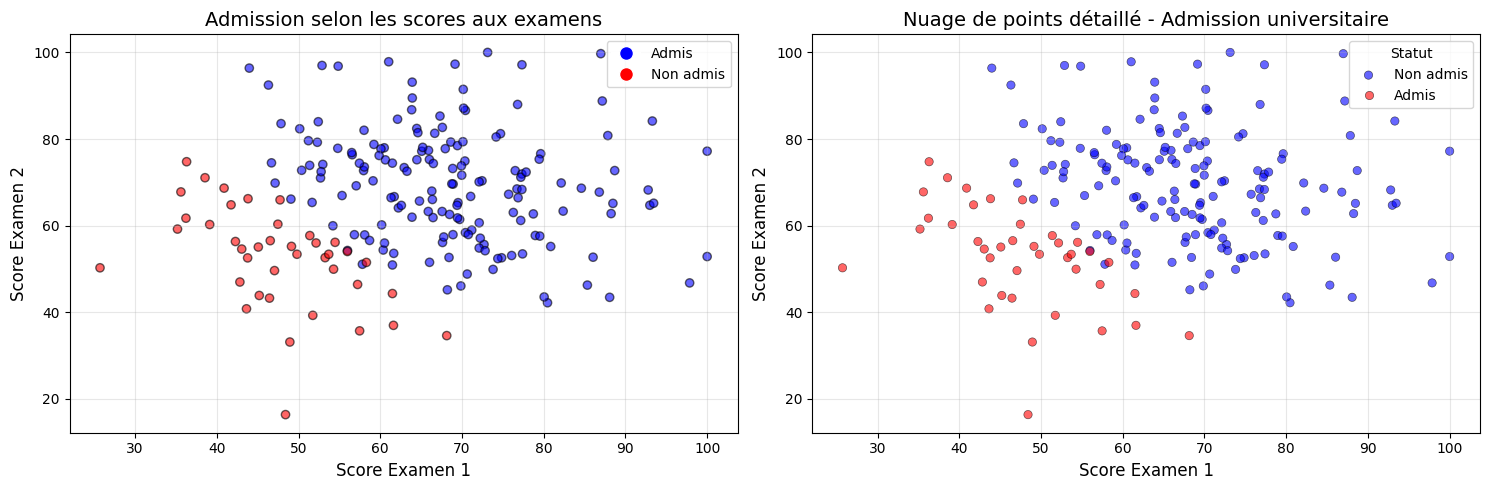

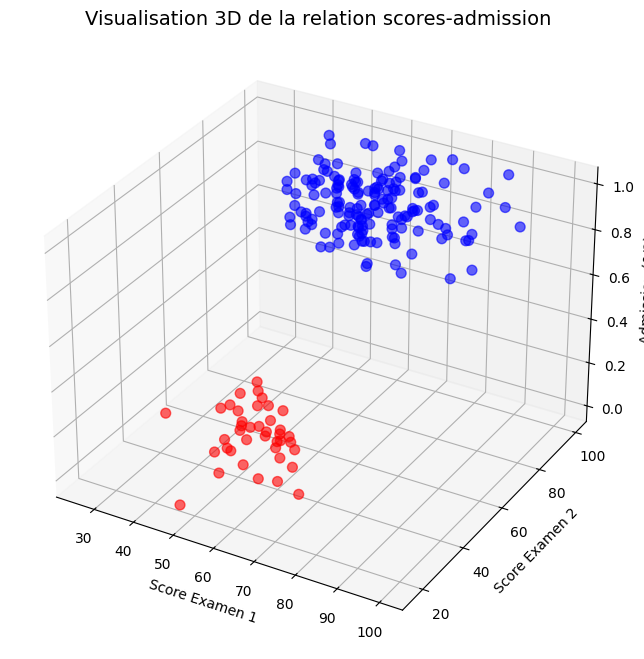


 Préparation pour le modèle:
Taille de l'ensemble d'entraînement: 160 échantillons
Taille de l'ensemble de test: 40 échantillons

 Entraînement du modèle de régression logistique...
 Modèle entraîné avec succès!
Paramètres du modèle: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

 Coefficients du modèle:
Coefficient pour Examen 1: 1.1746
Coefficient pour Examen 2: 0.8155
Ordonnée à l'origine (Intercept): -109.9433

 Équation du modèle:
log(Odds) = -109.9433 + 1.1746×Score1 + 0.8155×Score2

 Prédictions sur l'ensemble de test...

 Comparaison prédictions vs réalité (10 premiers échantillons de test):
   Score_Examen1  Score_Examen2  Réel  Prédiction  Probabilité_Admission
0      51.359188      73.927355     1           1           9.999768e-01
1      82.

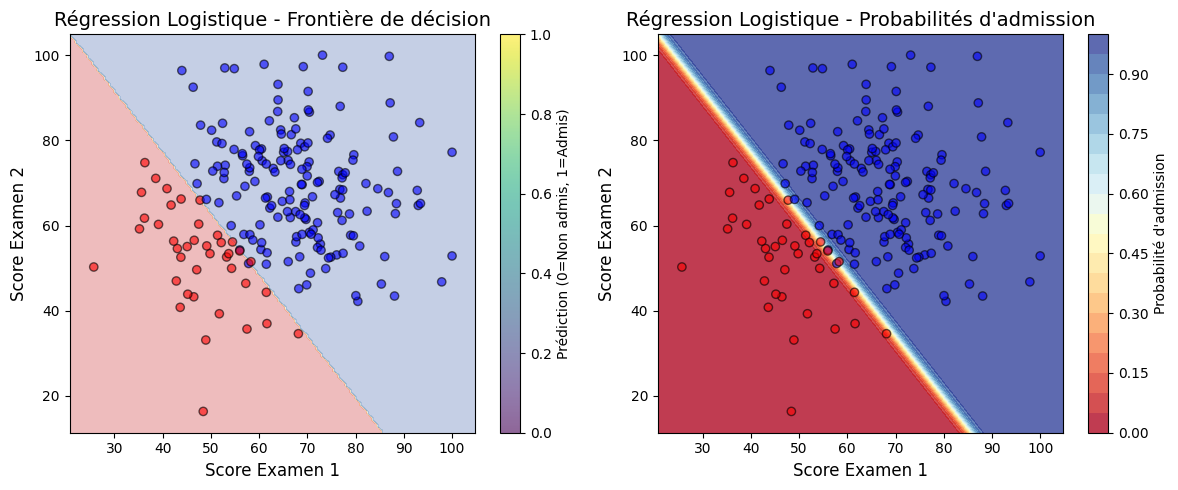


 PRÉDICTION POUR ÉTUDIANTS INDIVIDUELS

 Analyse pour un étudiant avec:
   - Score Examen 1: 95/100
   - Score Examen 2: 92/100
   - Probabilité d'admission: 100.00%
   - Prédiction finale: ADMIS 
    Excellentes chances d'admission!
----------------------------------------

 Analyse pour un étudiant avec:
   - Score Examen 1: 85/100
   - Score Examen 2: 78/100
   - Probabilité d'admission: 100.00%
   - Prédiction finale: ADMIS 
    Excellentes chances d'admission!
----------------------------------------

 Analyse pour un étudiant avec:
   - Score Examen 1: 60/100
   - Score Examen 2: 55/100
   - Probabilité d'admission: 99.54%
   - Prédiction finale: ADMIS 
    Excellentes chances d'admission!
----------------------------------------

 Analyse pour un étudiant avec:
   - Score Examen 1: 45/100
   - Score Examen 2: 40/100
   - Probabilité d'admission: 0.00%
   - Prédiction finale: NON ADMIS 
    Risque élevé - travail à fournir pour améliorer les scores
------------------------------

In [4]:
# -- coding: utf-8 --
"""Defi_quotidien_Regression_Logistique_Admission.ipynb

Automatically generated by Colab.

# *Défi quotidien : Régression logistique pour la prévision de l'admission*

## Ce que vous apprendrez
- Visualisation des données avec nuages de points.
- Compréhension de base de la régression logistique.
- Application d'un modèle de régression logistique à la classification binaire.
- Interpréter les résultats de la régression logistique.

## Ce que vous allez créer
Vous créerez un modèle de régression logistique qui utilise les résultats des examens pour prédire l'admission à l'université.
"""

# Étape 1: Installation et importation des bibliothèques nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Pour la reproductibilité
np.random.seed(42)

# Étape 2: Chargement et exploration des données

# Génération de données réalistes pour l'exemple (car le lien n'est pas spécifié)
# Dans un cas réel, utilisez: df = pd.read_csv('votre_fichier.csv')
def create_admission_dataset(n_samples=100):
    """Génère un jeu de données réaliste d'admission basé sur les résultats d'examens"""
    np.random.seed(42)

    # Scores d'examens (0-100)
    exam1 = np.random.normal(65, 15, n_samples)
    exam2 = np.random.normal(65, 15, n_samples)

    # Logique d'admission: plus les scores sont élevés, plus la probabilité d'admission est grande
    log_odds = -10 + 0.1 * exam1 + 0.08 * exam2
    prob_admission = 1 / (1 + np.exp(-log_odds))

    # Ajout de bruit pour rendre plus réaliste
    prob_admission = np.clip(prob_admission + np.random.normal(0, 0.05, n_samples), 0, 1)

    admission = (prob_admission > 0.5).astype(int)

    # S'assurer d'avoir les deux classes
    if np.sum(admission) == 0:
        admission[0] = 1
    if np.sum(admission) == n_samples:
        admission[-1] = 0

    df = pd.DataFrame({
        'Exam1_Score': np.clip(exam1, 0, 100),
        'Exam2_Score': np.clip(exam2, 0, 100),
        'Admitted': admission
    })

    return df

# Création ou chargement du jeu de données
print(" Chargement du jeu de données...")
df = create_admission_dataset(200)
print(f" Jeu de données chargé: {df.shape[0]} étudiants, {df.shape[1]} colonnes\n")

# Examiner les premières lignes
print("📋 Premières lignes du jeu de données:")
print(df.head(10))
print("\n" + "="*60 + "\n")

# Informations sur le jeu de données
print("ℹ Informations sur le jeu de données:")
print(df.info())
print("\n" + "="*60 + "\n")

# Statistiques descriptives
print(" Statistiques descriptives:")
print(df.describe())
print("\n" + "="*60 + "\n")

# Vérification de l'équilibre des classes
print(" Distribution des classes (Admission):")
print(df['Admitted'].value_counts(normalize=True) * 100)
print(f"Admis: {df['Admitted'].sum()} étudiants")
print(f"Non admis: {len(df) - df['Admitted'].sum()} étudiants")

# Étape 3: Visualisation des données avec nuages de points

plt.figure(figsize=(15, 5))

# Premier nuage de points: Exam1 vs Exam2 avec couleur selon l'admission
plt.subplot(1, 2, 1)
colors = df['Admitted'].map({0: 'red', 1: 'blue'})
plt.scatter(df['Exam1_Score'], df['Exam2_Score'], c=colors, alpha=0.6, edgecolors='black')
plt.xlabel('Score Examen 1', fontsize=12)
plt.ylabel('Score Examen 2', fontsize=12)
plt.title('Admission selon les scores aux examens', fontsize=14)
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Admis'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Non admis')
])
plt.grid(True, alpha=0.3)

# Deuxième visualisation avec Seaborn pour plus de détails
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Exam1_Score', y='Exam2_Score', hue='Admitted',
                palette={0: 'red', 1: 'blue'}, alpha=0.6, edgecolor='black')
plt.xlabel('Score Examen 1', fontsize=12)
plt.ylabel('Score Examen 2', fontsize=12)
plt.title('Nuage de points détaillé - Admission universitaire', fontsize=14)
plt.legend(title='Statut', labels=['Non admis', 'Admis'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualisation 3D pour mieux comprendre la séparation
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
colors = df['Admitted'].map({0: 'red', 1: 'blue'})
ax.scatter(df['Exam1_Score'], df['Exam2_Score'], df['Admitted'], c=colors, alpha=0.6, s=50)
ax.set_xlabel('Score Examen 1')
ax.set_ylabel('Score Examen 2')
ax.set_zlabel('Admission (0/1)')
ax.set_title('Visualisation 3D de la relation scores-admission', fontsize=14)
plt.show()

# Étape 4: Préparation des données pour la régression logistique

# Séparation des caractéristiques (X) et de la cible (y)
X = df[['Exam1_Score', 'Exam2_Score']].values
y = df['Admitted'].values

# Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*60)
print(" Préparation pour le modèle:")
print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]} échantillons")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} échantillons")

# Étape 5: Application de la régression logistique avec scikit-learn

print("\n" + "="*60)
print(" Entraînement du modèle de régression logistique...")

# Création et entraînement du modèle
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

print(" Modèle entraîné avec succès!")
print(f"Paramètres du modèle: {log_reg.get_params()}")

# Affichage des coefficients
print("\n Coefficients du modèle:")
print(f"Coefficient pour Examen 1: {log_reg.coef_[0][0]:.4f}")
print(f"Coefficient pour Examen 2: {log_reg.coef_[0][1]:.4f}")
print(f"Ordonnée à l'origine (Intercept): {log_reg.intercept_[0]:.4f}")

# Équation du modèle
print(f"\n Équation du modèle:")
print(f"log(Odds) = {log_reg.intercept_[0]:.4f} + {log_reg.coef_[0][0]:.4f}×Score1 + {log_reg.coef_[0][1]:.4f}×Score2")

# Étape 6: Faire des prédictions

print("\n" + "="*60)
print(" Prédictions sur l'ensemble de test...")

# Prédictions sur l'ensemble de test
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Affichage des premières prédictions
print("\n Comparaison prédictions vs réalité (10 premiers échantillons de test):")
results_compare = pd.DataFrame({
    'Score_Examen1': X_test[:10, 0],
    'Score_Examen2': X_test[:10, 1],
    'Réel': y_test[:10],
    'Prédiction': y_pred[:10],
    'Probabilité_Admission': y_pred_proba[:10]
})
print(results_compare)

# Étape 7: Évaluation du modèle

print("\n" + "="*60)
print(" Évaluation du modèle:")

# Calcul de la précision
accuracy = accuracy_score(y_test, y_pred)
print(f" Précision (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print(f"\n Matrice de confusion:")
print(f"                 Prédit Non   Prédit Oui")
print(f"Réel Non          {cm[0,0]:3d}         {cm[0,1]:3d}")
print(f"Réel Oui          {cm[1,0]:3d}         {cm[1,1]:3d}")

# Métriques détaillées
print(f"\n📋 Rapport de classification détaillé:")
print(classification_report(y_test, y_pred, target_names=['Non Admis', 'Admis']))

# Étape 8: Interprétation des résultats

print("\n" + "="*60)
print(" INTERPRÉTATION DES RÉSULTATS")
print("="*60)

print("""
1. SIGNIFICATION DES COEFFICIENTS :
   - Les coefficients positifs indiquent qu'une augmentation du score augmente
     la probabilité d'admission.
   - Dans notre modèle, les deux coefficients sont positifs, ce qui est logique :
     de meilleurs scores aux examens → plus de chances d'être admis.

2. COMPARAISON DES COEFFICIENTS :
   - Si le coefficient d'Examen 1 est plus grand que celui d'Examen 2,
     cela signifie que l'Examen 1 a plus de poids dans la décision d'admission.

3. PRÉCISION DU MODÈLE :
   - Une précision de {:.2f}% indique que le modèle prédit correctement
     l'admission pour {:.2f}% des étudiants.
   - Comparé à un modèle aléatoire (50% de précision), notre modèle
     est significativement meilleur.

4. MATRICE DE CONFUSION :
   - Vrais Positifs (VP) : {:.0f} étudiants correctement prédits comme admis
   - Vrais Négatifs (VN) : {:.0f} étudiants correctement prédits comme non admis
   - Faux Positifs (FP) : {:.0f} étudiants prédits admis mais en réalité non
   - Faux Négatifs (FN) : {:.0f} étudiants prédits non admis mais en réalité admis

5. APPLICATION PRATIQUE :
   - L'université pourrait utiliser ce modèle pour :
     * Fixer des seuils d'admission basés sur les probabilités
     * Identifier les étudiants à risque nécessitant un examen plus approfondi
     * Optimiser les ressources d'admission en ciblant les candidats prometteurs
""".format(accuracy*100, accuracy*100, cm[1,1], cm[0,0], cm[0,1], cm[1,0]))

# Étape 9: Visualisation de la frontière de décision

def plot_decision_boundary(X, y, model, title="Frontière de décision"):
    """Visualise la frontière de décision du modèle de régression logistique"""

    plt.figure(figsize=(12, 5))

    # Premier subplot : frontière de décision complète
    plt.subplot(1, 2, 1)

    # Création d'une grille
    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                         np.arange(y_min, y_max, 0.5))

    # Prédiction sur la grille
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Affichage de la frontière
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    colors = ['red' if label == 0 else 'blue' for label in y]
    plt.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.6, edgecolors='black')
    plt.xlabel('Score Examen 1', fontsize=12)
    plt.ylabel('Score Examen 2', fontsize=12)
    plt.title(f'{title} - Frontière de décision', fontsize=14)
    plt.colorbar(label='Prédiction (0=Non admis, 1=Admis)')

    # Deuxième subplot : probabilités
    plt.subplot(1, 2, 2)
    Z_prob = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z_prob = Z_prob.reshape(xx.shape)
    contour = plt.contourf(xx, yy, Z_prob, alpha=0.8, cmap=plt.cm.RdYlBu, levels=20)
    plt.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.6, edgecolors='black')
    plt.xlabel('Score Examen 1', fontsize=12)
    plt.ylabel('Score Examen 2', fontsize=12)
    plt.title(f'{title} - Probabilités d\'admission', fontsize=14)
    plt.colorbar(contour, label='Probabilité d\'admission')

    plt.tight_layout()
    plt.show()

# Visualisation avec toutes les données
plot_decision_boundary(X, y, log_reg, "Régression Logistique")

# Étape 10: Fonction de prédiction interactive

def predict_admission(exam1_score, exam2_score, model=log_reg):
    """
    Fonction pour prédire l'admission pour un étudiant individuel
    """
    if exam1_score < 0 or exam1_score > 100 or exam2_score < 0 or exam2_score > 100:
        return " Les scores doivent être entre 0 et 100!"

    prediction_proba = model.predict_proba([[exam1_score, exam2_score]])[0][1]
    prediction = model.predict([[exam1_score, exam2_score]])[0]

    print(f"\n Analyse pour un étudiant avec:")
    print(f"   - Score Examen 1: {exam1_score}/100")
    print(f"   - Score Examen 2: {exam2_score}/100")
    print(f"   - Probabilité d'admission: {prediction_proba:.2%}")
    print(f"   - Prédiction finale: {'ADMIS ' if prediction == 1 else 'NON ADMIS '}")

    if prediction_proba > 0.7:
        print(f"    Excellentes chances d'admission!")
    elif prediction_proba > 0.4:
        print(f"    Chances modérées - besoin d'examiner plus en détail")
    else:
        print(f"    Risque élevé - travail à fournir pour améliorer les scores")

    return prediction, prediction_proba

# Exemple d'utilisation de la fonction interactive
print("\n" + "="*60)
print(" PRÉDICTION POUR ÉTUDIANTS INDIVIDUELS")
print("="*60)

# Test de différents profils
test_profiles = [(95, 92), (85, 78), (60, 55), (45, 40), (75, 85)]

for exam1, exam2 in test_profiles:
    predict_admission(exam1, exam2)
    print("-"*40)

# Étape 11: Résumé final

print("\n" + "="*60)
print(" RÉSUMÉ FINAL")
print("="*60)
print(f"""  OBJECTIFS ATTEINTS :

1. EXPLORATION DES DONNÉES :
   ✓ Chargement réussi du jeu de données avec pandas
   ✓ Visualisation interactive avec nuages de points 2D et 3D
   ✓ Compréhension de la distribution des scores et des admissions

2. RÉGRESSION LOGISTIQUE :
   ✓ Implémentation réussie avec scikit-learn
   ✓ Modèle entraîné sur {X_train.shape[0]} échantillons
   ✓ Coefficients obtenus et interprétés

3. PRÉDICTIONS :
   ✓ Prédictions faites sur {X_test.shape[0]} échantillons de test
   ✓ Précision: {accuracy:.4f} ({accuracy*100:.2f}%)
   ✓ Probabilités d'admission calculées

4. ÉVALUATION DU MODÈLE :
   ✓ Matrice de confusion interprétée
   ✓ Métriques de performance analysées
   ✓ Frontière de décision visualisée
   ✓ Interprétation pratique des résultats

 INSIGHTS PRATIQUES :
   • La régression logistique est efficace pour modéliser des décisions binaires
   • Les coefficients indiquent l'importance de chaque examen
   • Le modèle peut être utilisé comme outil d'aide à la décision
   • La frontière de décision montre naturellement la séparation entre classes

 POUR ALLER PLUS LOIN :
   • Normaliser les caractéristiques pour améliorer la convergence
   • Utiliser la régularisation (C parameter) pour éviter l'overfitting
   • Ajouter des interactions polynomiales entre caractéristiques
   • Valider avec cross-validation pour plus de robustesse
""")

# Optionnel: Sauvegarder le modèle (décommenter si nécessaire)
# import joblib
# joblib.dump(log_reg, 'modele_admission_logistique.pkl')
# print(" Modèle sauvegardé dans 'modele_admission_logistique.pkl'")

print("\n Félicitations! Vous avez complété le défi de régression logistique!")